<div style="font-weight: bold; color:#5D8AA8" align="center">
    <div style="font-size: xx-large">Métodos Funcionales en Aprendizaje Automático</div><br>
    <div style="font-size: x-large; color:gray">Homework 03 - Diffusion Maps</div><br>
    <div style="font-size: large">Authors</div><br>Sergio Fernández Munguía e Iñigo Martínez Ciriza</div><hr>
</div>

**Initial Configuration**

This cell defines the configuration of Jupyter Notebooks.

In [1]:
%%html
<style>
    .qst {background-color: #b1cee3; padding:10px; border-radius: 5px; border: solid 2px #5D8AA8;}
    .qst:before {font-weight: bold; content:"Exercise"; display: block; margin: 0px 10px 10px 10px;}
    h1, h2, h3 {color: #5D8AA8;}
    .text_cell_render p {text-align: justify; text-justify: inter-word;}
</style>

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

This cell imports the packages to be used.

In [3]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors

from sklearn.datasets import make_blobs, make_swiss_roll, make_s_curve

from mpl_toolkits.mplot3d import Axes3D
Axes3D

matplotlib.rc('figure', figsize=(15, 5))

seed = 123
my_cmap = plt.cm.Spectral

# Introduction

This practical assignment is about implementing the manifold learning method **Diffusion Maps**, following the *scikit-learn* template for manifold learning algorithms.

We will design two main functions: one for training the algorithm, obtaining the affinity matrix and the embedded coordinates, and a second one for extending these coordinates for new patterns.

# Requirements

The objective of this assignment is to complete the class DM sketched below, which should contain at least the following methods.

`__init__(self, sigma, n_components, step=1, alpha=1)`

* This is the construction method for the class, with the following parameters:
    * `sigma`: Kernel parameter for the Gaussian kernel.
    * `n_components`: dimension of the embedding.
    * `step`: step in the Markov Chain.
    * `alpha`: density influence. It should take a value in `[0,1]`.
* This method just store the parameters in the fields of the class, to be used when needed.

`fit(self, X, y=None)`

* This is the training method, the one that performs the Diffusion Maps algorithm. 

* This method should store the affinity matrix and also the eigenvectors to computed the transformation.

`fit_transform(self, X, y=None)`

* This method returns the embedding coordinates for the training data.
* It should also store the affinity matrix and the coordinates needed to compute the transformation (for example over new, unseen patterns).

`transform(self, X)`

* This method will obtain approximated coordinates for new, unseen data points. 
* It uses for this purpose the Nyström Formula.

## Some recommendations

* It should allow to fix all the DM possibilities (different steps, density normalization...). To allow a change in the kernel function could be also a nice idea.
* Implement all the auxiliary functions that you may need, for example, for deciding the best parameter values in each case.
* It could be a nice idea to offer a deterministic output, that do not depend on the sign of the eigenvectors.

# Implementation

<div class="qst">

* Complete the `DM` class below, satisfying the described requirements.

</div>

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin

class DM(TransformerMixin, BaseEstimator):
    """
        Diffusion Maps.
    """
    def __init__(self, sigma, n_components, alpha, step=1):
        # Assignment of the hyper-parameters
        self.sigma = sigma
        self.n_components = n_components
        self.step = step
        self.alpha = alpha

    def fit(self, X, y=None):
        """Compute the embedding vectors for data X
        Parameters
        ----------
        X : array-like of shape [n_samples, n_features]
            training set.
        y : Ignored
        Returns
        -------
        self : returns an instance of self.
        """
        self.X_ = X

        # Gaussian kernel
        dists2 = np.sum(X**2, axis=1, keepdims=True) + np.sum(X**2, axis=1) - 2 * np.dot(X, X.T)
        K = np.exp(-dists2 / (self.sigma**2))
        
        # Degree of each node kernel (save them for tranform)
        d = np.sum(K, axis=1)
        self.d_ = d
        
        # Normalized kernel
        K_tilde = K / (d[:, None]**self.alpha * d[None, :]**self.alpha)
        
        # Degree of each node of normalized kernel
        d_tilde = np.sum(K_tilde, axis=1)
        
        # Transition probability matrix
        P = K_tilde / d_tilde[:, None]
        
        # Eigen decomposition of P
        eigenvalues, eigenvectors = np.linalg.eig(P)
        # Ensure real values
        eigenvalues = eigenvalues.real
        eigenvectors = eigenvectors.real
        # Sort eigenvalues
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        # Save the eigenvalues and eigenvectors
        self.lambdas_ = eigenvalues
        self.psi_ = eigenvectors
        
        # Compute the diffusion map for training data
        self.embedding_ = self.psi_[:, 1:self.n_components+1] * (self.lambdas_[1:self.n_components+1] ** self.step)
        
        return self
    
    def fit_transform(self, X, y=None):
        """Compute the embedding vectors for data X and transform X.
        Parameters
        ----------
        X : array-like of shape [n_samples, n_features]
            training set.
        y : Ignored
        Returns
        -------
        X_red : array-like, shape (n_samples, n_components)
        """
        self.fit(X, y)
        X_red = self.embedding_
        return X_red
    
    def transform(self, Y):
        """Transform Y.
        This function is implemented using the Nyström formula.
        Parameters
        ----------
        Y : array-like, shape (n_samples, n_features).
        Returns
        -------
        Y_red : array-like, shape (n_samples, n_components)
        """
        # Gaussian kernel beteween new points and training data
        dists2_y = np.sum(Y**2, axis=1, keepdims=True) + np.sum(self.X_**2, axis=1) - 2 * np.dot(Y, self.X_.T)
        K_y = np.exp(-dists2_y / (self.sigma**2))
        
        # Degree of each new point
        d_y = np.sum(K_y, axis=1)
        
        # Normalized kernel
        K_y_tilde = K_y / (d_y[:, None]**self.alpha * self.d_[None, :]**self.alpha)
        
        # Degree of each node of normalized kernel
        d_y_tilde = np.sum(K_y_tilde, axis=1)
        
        # Transition probability matrix
        P_y = K_y_tilde / d_y_tilde[:, None]

        # Nyström formula
        lam = self.lambdas_[1:self.n_components+1]
        psi_train = self.psi_[:, 1:self.n_components+1]
        Y_red = (P_y.dot(psi_train)) * (lam**(self.step - 1))
        
        return Y_red

# Experiments with DM

<div class="qst">

* Obtain some good embedded coordinates for the three training datasets specified below.
    
* Extend its coordinates for the new points.
    
</div>

## Dataset 1: two blobs

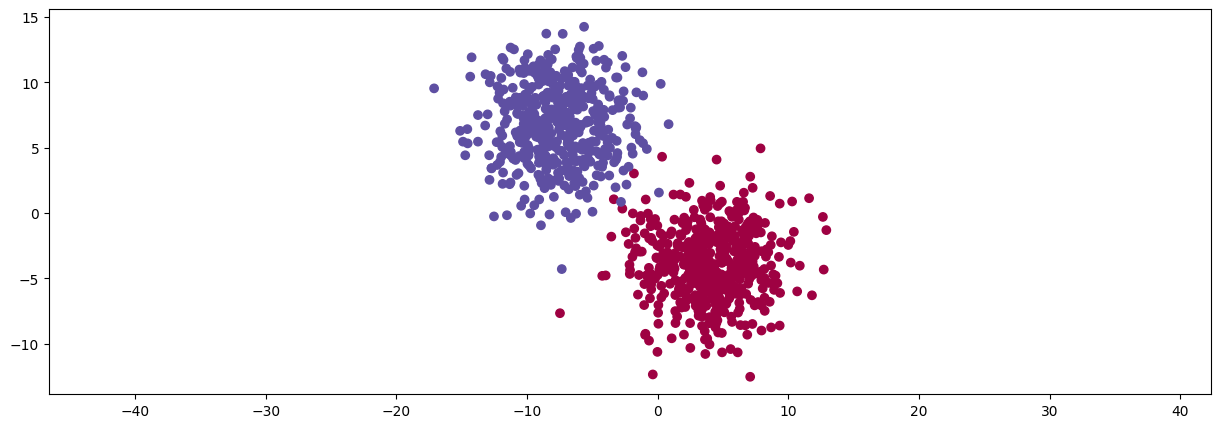

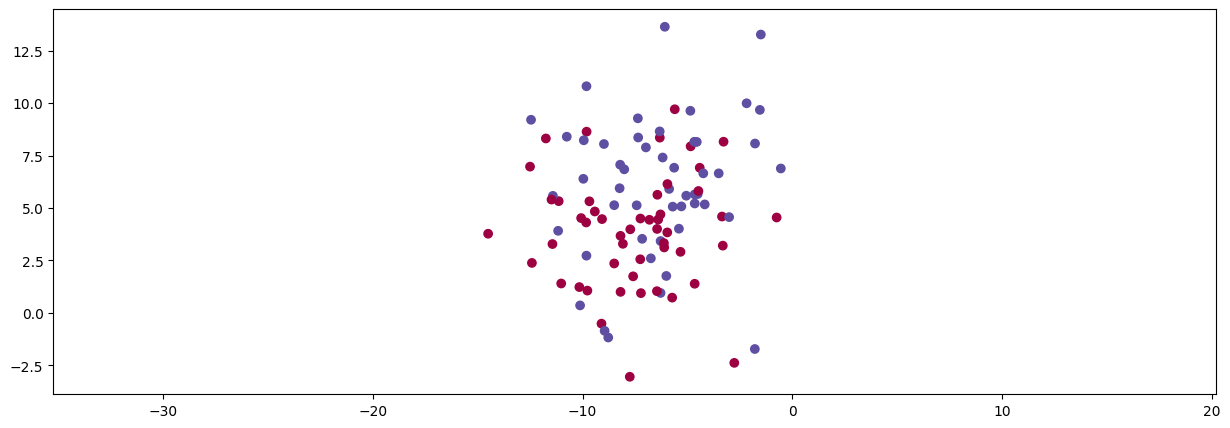

In [5]:
N = 1000

X, y = make_blobs(n_samples=N, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed)
y[y != 1] = -1
plt.scatter(X[:,0], X[:,1], c=y, cmap=my_cmap)
plt.axis('equal')
plt.show()

N_new=100
X_new, y_new = make_blobs(n_samples=N_new, n_features=50, centers=2,
                  cluster_std=3.0, random_state=seed+1)
plt.scatter(X_new[:,0], X_new[:,1], c=y_new, cmap=my_cmap)
plt.axis('equal')
plt.show()

/tmp/ipykernel_73569/338696190.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


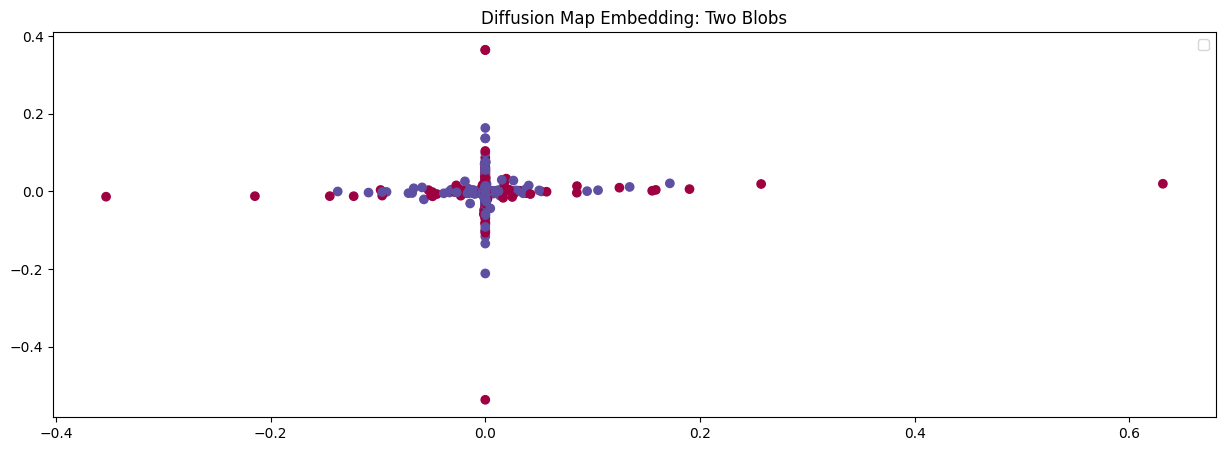

/tmp/ipykernel_73569/338696190.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


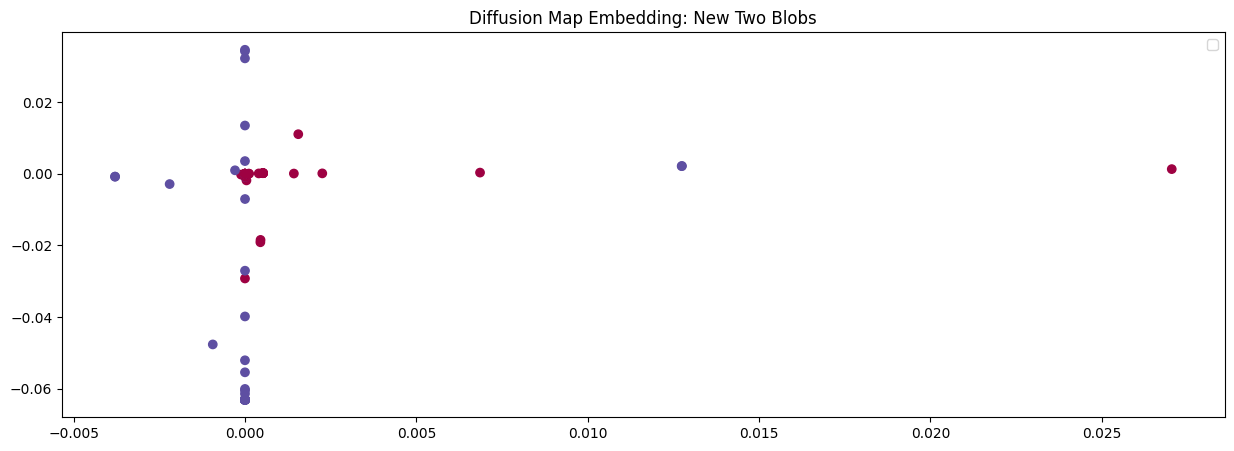

In [6]:
#Solution here

# Set hyperparameters
alpha_1 = 0.5
sigma_1 = 3.0
n_components_1 = 2
step_1 = 1

# Create diffusion map instance and embed training data
dm_blob = DM(sigma=sigma_1,
             n_components=n_components_1,
             alpha = alpha_1)
X_red_blob = dm_blob.fit_transform(X)

# Extend the embedding to new points
X_new_red_blob = dm_blob.transform(X_new)

# Plot the embedding
plt.figure()
plt.scatter(X_red_blob[:,0], X_red_blob[:,1], c=y, cmap=my_cmap)
plt.title("Diffusion Map Embedding: Two Blobs")
plt.legend()
plt.show()

# Plot the embeddings for the new points
plt.figure()
plt.scatter(X_new_red_blob[:,0], X_new_red_blob[:,1], c=y_new, cmap=my_cmap)
plt.title("Diffusion Map Embedding: New Two Blobs")
plt.legend()
plt.show()

## Dataset 2: the swiss roll

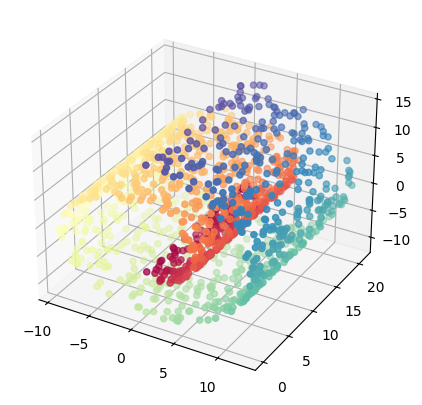

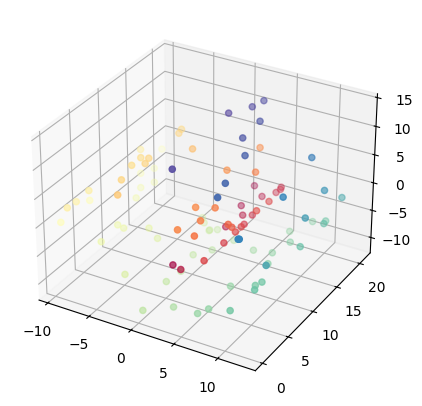

In [7]:
N=1500
X, color = make_swiss_roll(n_samples=N, random_state=seed)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=my_cmap)
plt.show()

N_new=100
X_new, color_new = make_swiss_roll(n_samples=N_new, random_state=seed+1)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=color_new, cmap=my_cmap)
plt.show()


/tmp/ipykernel_73569/2186611960.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


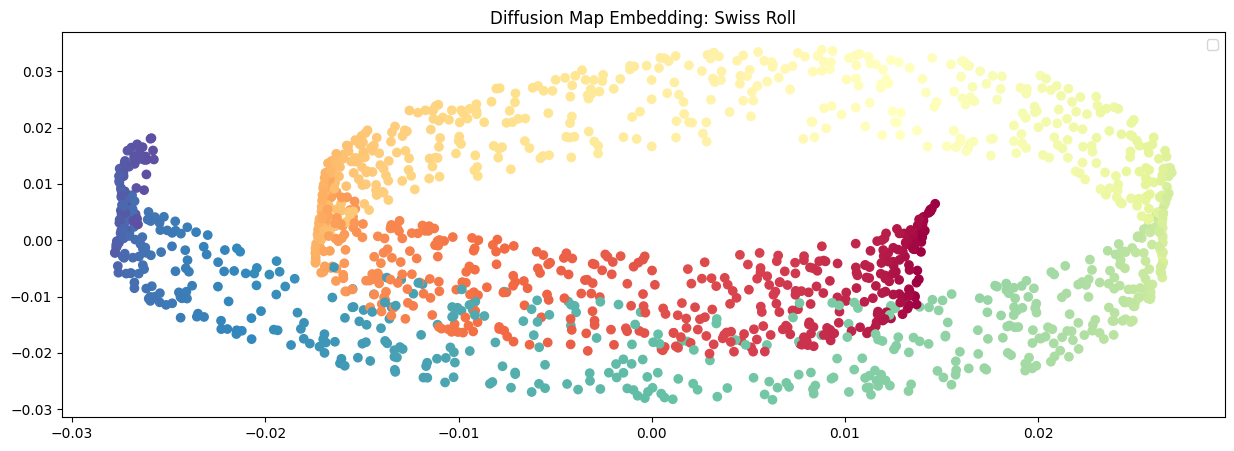

/tmp/ipykernel_73569/2186611960.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


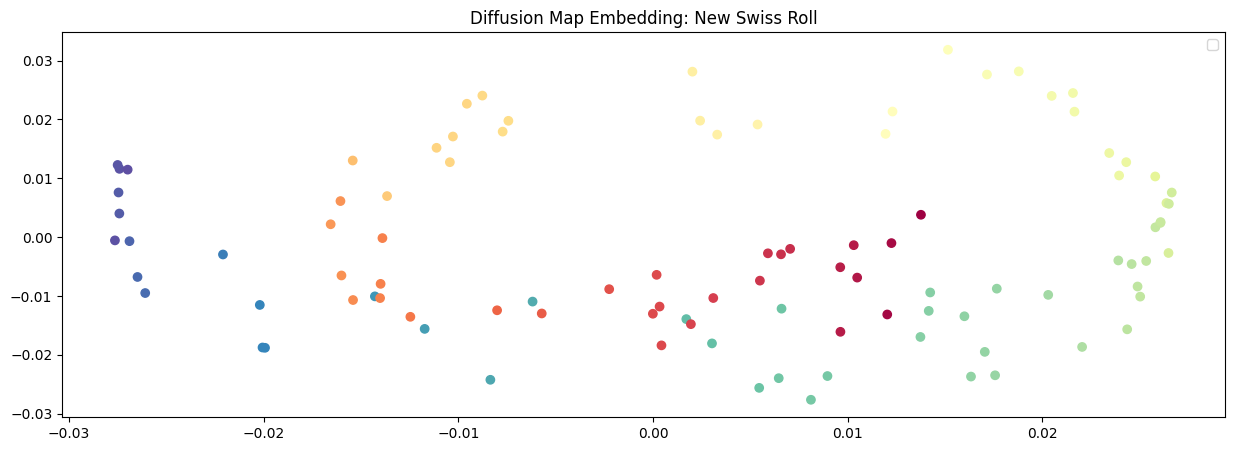

In [8]:
#Solution here

# Set hyperparameters (tuning sigma is critical; here we use sigma=10)
alpha_2 = 0.5
sigma_2 = 10.0
n_components_2 = 2
step_2 = 1

dm_swiss = DM(sigma=sigma_2, n_components=n_components_2, step=step_2, alpha=alpha_2)
X_red_swiss = dm_swiss.fit_transform(X)
X_new_red_swiss = dm_swiss.transform(X_new)

# Plot the embedding
plt.figure()
plt.scatter(X_red_swiss[:,0], X_red_swiss[:,1], c=color, cmap=my_cmap)
plt.title("Diffusion Map Embedding: Swiss Roll")
plt.legend()
plt.show()

# Plot the embedding for the new points
plt.figure()
plt.scatter(X_new_red_swiss[:,0], X_new_red_swiss[:,1], c=color_new, cmap=my_cmap)
plt.title("Diffusion Map Embedding: New Swiss Roll")
plt.legend()
plt.show()


## Dataset 3: the S curve

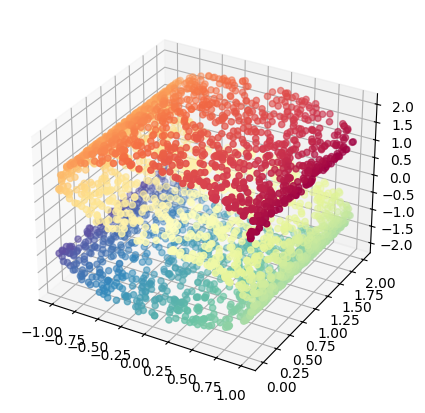

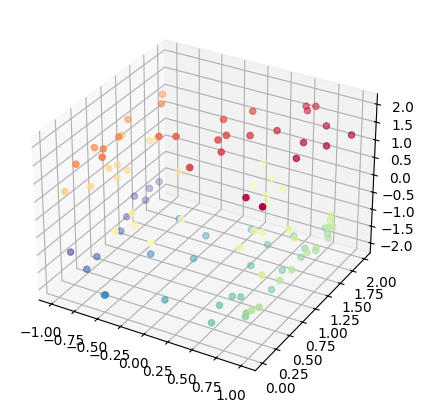

In [9]:
N = 3000
X, color = make_s_curve(N, random_state=seed)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=my_cmap)
plt.show()

N_new = 100
X_new, color_new = make_s_curve(N_new, random_state=seed+1)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_new[:, 0], X_new[:, 1], X_new[:, 2], c=color_new, cmap=my_cmap)
plt.show()

/tmp/ipykernel_73569/2008077685.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


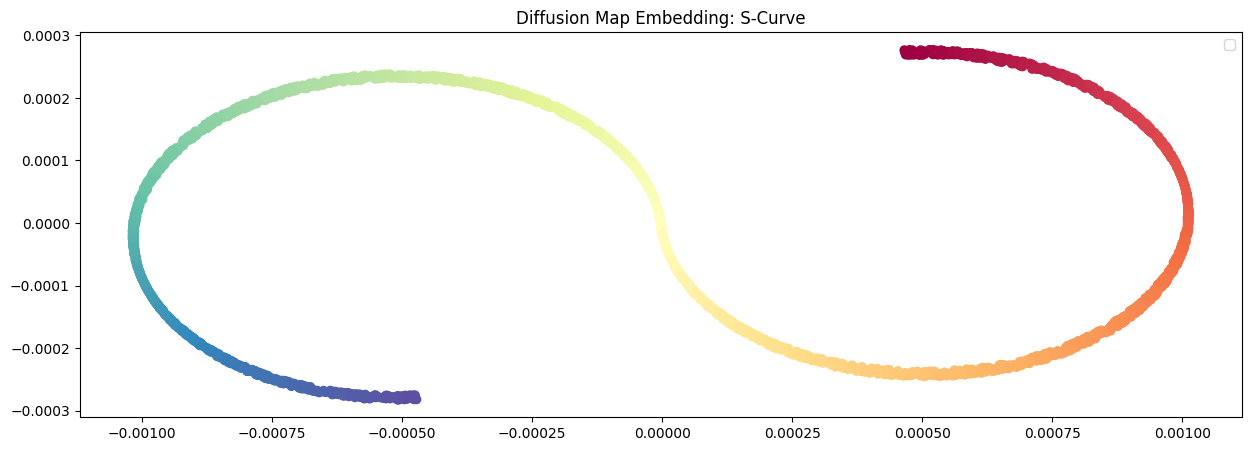

/tmp/ipykernel_73569/2008077685.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


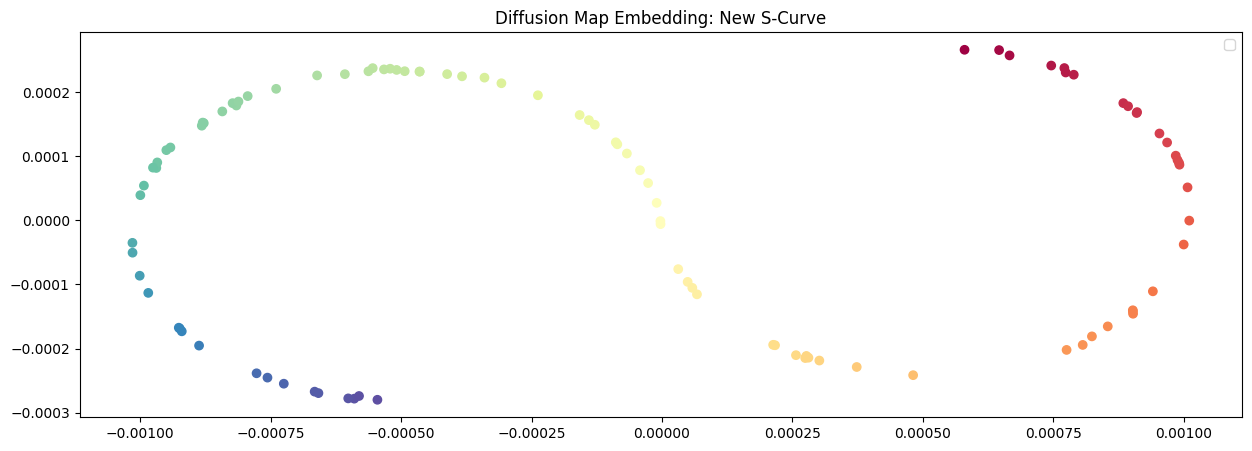

In [10]:
#Solution here

# For the S-curve we use similar hyperparameters to the swiss roll
alpha_3 = 0.5
sigma_3 = 10.0
n_components_3 = 2
step_3 = 1

dm_scurve = DM(sigma=sigma_3, n_components=n_components_3, step=step_3, alpha=alpha_3)
X_red_scurve = dm_scurve.fit_transform(X)
X_new_red_scurve = dm_scurve.transform(X_new)

# Plot the embedding
plt.figure()
plt.scatter(X_red_scurve[:,0], X_red_scurve[:,1], c=color, cmap=my_cmap)
plt.title("Diffusion Map Embedding: S-Curve")
plt.legend()
plt.show()

# Plot the embedding for the new points
plt.figure()
plt.scatter(X_new_red_scurve[:,0], X_new_red_scurve[:,1], c=color_new, cmap=my_cmap)
plt.title("Diffusion Map Embedding: New S-Curve")
plt.legend()
plt.show()

<div class="qst">

1. Do you consider that the embedding obtained is good for the previous datasets? Is it the expected one? Why?
    
    
2. How sensible is the method to its hyper-parameters? Specify the best values that you have found and the technique employed for it.
    * Check how much influence has the sample density (you can vary N for each dataset).
    * Check what happens if the number of steps `steps` grows.
   
    
3. In your opinion, which is the main advantage and disadvantage of this method?
    
</div>

**Answer**: